<a href="https://colab.research.google.com/github/RanaAAAli/bachelor-/blob/main/notebook71d6f1caa9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('EHR.csv')

print("Initial Dataset Shape:", df.shape)
df.head()

Saving EHR.csv to EHR (6).csv
Initial Dataset Shape: (1447, 29)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,210014,182373,Male,45,Caucasian,73,89,"Hypertension, uncontrolled (for cerebrovascula...",178.0,13:08:59,...,Direct Admit,1,admit,116.0,112.7,15:00:00,4424,Skilled Nursing Facility,Alive,002-10665
1,200026,174624,Male,50,Caucasian,71,87,Ablation or mapping of cardiac conduction pathway,177.8,10:41:00,...,Operating Room,1,admit,106.1,106.1,17:40:00,1548,Home,Alive,002-10715
2,221131,190993,Male,83,Caucasian,71,87,"Endarterectomy, carotid",175.3,21:43:00,...,Operating Room,1,admit,NaN,72.1,17:46:00,1203,Home,Alive,002-10249
3,221215,191054,Male,49,Caucasian,71,87,"Infarction, acute myocardial (MI)",185.4,03:16:00,...,Emergency Department,1,admit,145.3,146.6,19:07:00,1562,Home,Alive,002-10627
4,217835,188445,Male,57,Caucasian,73,92,"CABG alone, coronary artery bypass grafting",172.7,01:09:00,...,Operating Room,1,admit,NaN,80.4,08:25:00,4719,Floor,Alive,002-10324


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447 entries, 0 to 1446
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientunitstayid          1447 non-null   int64  
 1   patienthealthsystemstayid  1447 non-null   int64  
 2   gender                     1444 non-null   object 
 3   age                        1446 non-null   object 
 4   ethnicity                  1405 non-null   object 
 5   hospitalid                 1447 non-null   int64  
 6   wardid                     1447 non-null   int64  
 7   apacheadmissiondx          1267 non-null   object 
 8   admissionheight            1402 non-null   float64
 9   hospitaladmittime24        1447 non-null   object 
 10  hospitaladmitoffset        1447 non-null   int64  
 11  hospitaladmitsource        1218 non-null   object 
 12  hospitaldischargeyear      1447 non-null   int64  
 13  hospitaldischargetime24    1447 non-null   objec

In [95]:
print("Missing Values:\n", df.isnull().sum())


Missing Values:
 patientunitstayid              0
patienthealthsystemstayid      0
gender                         3
age                            1
ethnicity                     42
hospitalid                     0
wardid                         0
apacheadmissiondx            180
admissionheight               45
hospitaladmittime24            0
hospitaladmitoffset            0
hospitaladmitsource          229
hospitaldischargeyear          0
hospitaldischargetime24        0
hospitaldischargeoffset        0
hospitaldischargelocation      8
hospitaldischargestatus        7
unittype                       0
unitadmittime24                0
unitadmitsource               19
unitvisitnumber                0
unitstaytype                   0
admissionweight              134
dischargeweight              576
unitdischargetime24            0
unitdischargeoffset            0
unitdischargelocation          5
unitdischargestatus            2
uniquepid                      0
dtype: int64


In [96]:
print("\nSummary Statistics:\n", df.describe())


Summary Statistics:
        patientunitstayid  patienthealthsystemstayid   hospitalid       wardid  \
count       1.447000e+03                1447.000000  1447.000000  1447.000000   
mean        6.464812e+05              494962.955079   139.385625   301.238424   
std         3.855454e+05              269873.698956    52.179555   158.898758   
min         1.424930e+05              129943.000000    69.000000    85.000000   
25%         2.647495e+05              227611.500000    92.000000   136.000000   
50%         4.212490e+05              359321.000000   112.000000   252.000000   
75%         1.056172e+06              782773.500000   194.000000   467.000000   
max         1.135186e+06              842932.000000   199.000000   495.000000   

       admissionheight  hospitaladmitoffset  hospitaldischargeyear  \
count      1402.000000          1447.000000            1447.000000   
mean        168.061591         -2133.019350            2014.651693   
std          13.442189          8498.2

In [97]:
# Split dataset into 3 hospitals
df_A = df.sample(frac=0.33, random_state=1)
remaining = df.drop(df_A.index)

df_B = remaining.sample(frac=0.5, random_state=2)
df_C = remaining.drop(df_B.index)

# Assign hospital labels
df_A['Hospital'] = 'Hospital_A'
df_B['Hospital'] = 'Hospital_B'
df_C['Hospital'] = 'Hospital_C'

# Introduce inconsistencies
df_B['gender'] = df_B['gender'].replace({'Male': 'M', 'Female': 'F'})
df_C['gender'] = df_C['gender'].astype(str).str.lower()

# Introduce missing values
df_A.loc[df_A.sample(frac=0.1).index, 'age'] = np.nan

# Diagnosis inconsistency
df_C['apacheadmissiondx'] = df_C['apacheadmissiondx'].astype(str).str.upper()

# Combine
df_fragmented = pd.concat([df_A, df_B, df_C], ignore_index=True)

print("Fragmented Dataset Shape:", df_fragmented.shape)

Fragmented Dataset Shape: (1447, 30)


In [98]:
# Standardize gender
df_fragmented['gender'] = df_fragmented['gender'].replace({
    'M': 'Male', 'F': 'Female',
    'male': 'Male', 'female': 'Female'
})

# Fix age
df_fragmented['age'] = pd.to_numeric(df_fragmented['age'], errors='coerce')
df_fragmented['age'] = df_fragmented['age'].fillna(df_fragmented['age'].median())

# Standardize diagnosis
df_fragmented['apacheadmissiondx'] = df_fragmented['apacheadmissiondx'].astype(str).str.lower()

# Handle missing values
df_fragmented['apacheadmissiondx'] = df_fragmented['apacheadmissiondx'].fillna("unknown")
df_fragmented['admissionweight'] = df_fragmented['admissionweight'].fillna(method='ffill')
df_fragmented['dischargeweight'] = df_fragmented['dischargeweight'].fillna(df_fragmented['admissionweight'])

# Remove duplicates
df_cleaned = df_fragmented.drop_duplicates(subset=['patienthealthsystemstayid']).copy()

print("Cleaned Dataset Shape:", df_cleaned.shape)

Cleaned Dataset Shape: (1242, 30)


/tmp/ipykernel_8774/563516158.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_fragmented['admissionweight'] = df_fragmented['admissionweight'].fillna(method='ffill')


In [99]:
# Length of stay
df_cleaned['length_of_stay_days'] = df_cleaned['unitdischargeoffset'] / (60 * 24)

# Age group
df_cleaned['age_group'] = pd.cut(df_cleaned['age'],
                                bins=[0,18,40,65,100],
                                labels=['Child','Young Adult','Adult','Senior'])

# Weight change
df_cleaned['weight_change'] = df_cleaned['dischargeweight'] - df_cleaned['admissionweight']

# Risk score
df_cleaned['risk_score'] = (
    (df_cleaned['length_of_stay_days'] > 7).astype(int) +
    (df_cleaned['age'] > 65).astype(int) +
    (df_cleaned['hospitaldischargestatus'] == 'Expired').astype(int)
)

df_cleaned['risk_level'] = pd.cut(df_cleaned['risk_score'],
                                 bins=[-1,1,2,3],
                                 labels=['Low','Medium','High'])

In [100]:
# Top diagnoses
df_cleaned['apacheadmissiondx'].value_counts().head(10)

# Hospital distribution
df_cleaned['Hospital'].value_counts()

# Average length of stay
df_cleaned.groupby('apacheadmissiondx')['length_of_stay_days'].mean().head(10)

# Mortality rate
(df_cleaned['hospitaldischargestatus'].value_counts(normalize=True) * 100)

,proportion
hospitaldischargestatus,
Alive,91.578947
Expired,8.421053


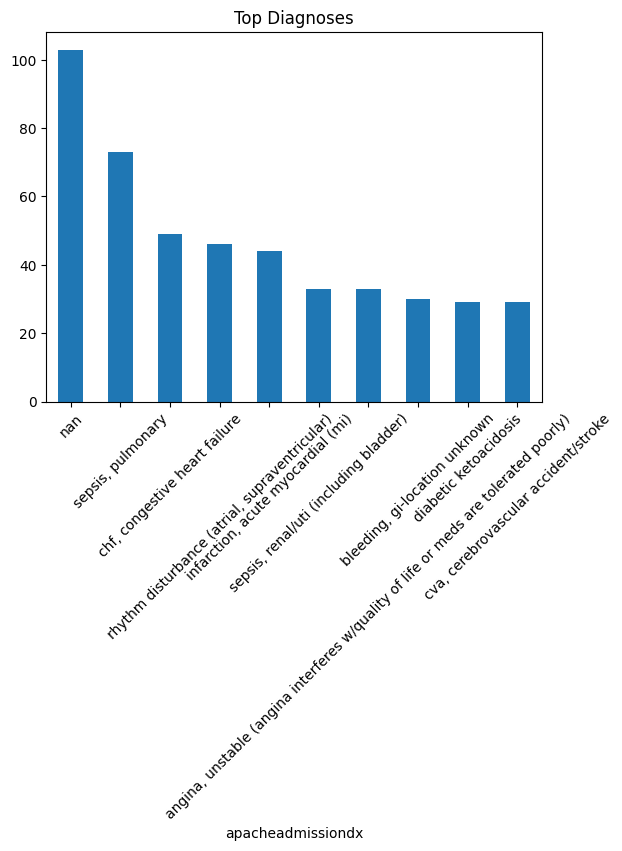

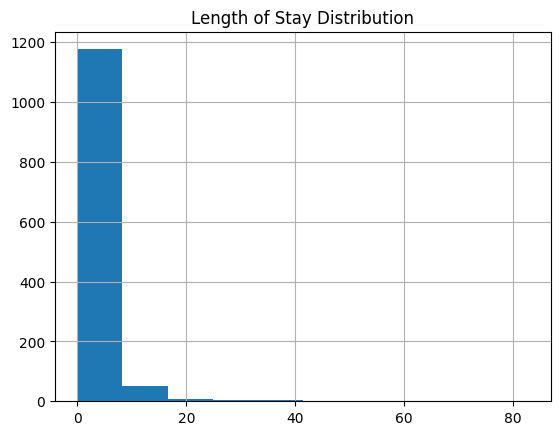

In [101]:
# Top diagnoses
df_cleaned['apacheadmissiondx'].value_counts().head(10).plot(kind='bar')
plt.title("Top Diagnoses")
plt.xticks(rotation=45)
plt.show()

# Length of stay
df_cleaned['length_of_stay_days'].hist()
plt.title("Length of Stay Distribution")
plt.show()

In [102]:
df_cleaned['high_risk_flag'] = df_cleaned['length_of_stay_days'] > 7

df_cleaned[['length_of_stay_days', 'high_risk_flag']].head()

,length_of_stay_days,high_risk_flag
0,1.080556,False
1,1.026389,False
2,3.352778,False
3,2.959722,False
4,0.006944,False


In [103]:
total_patients = df_cleaned['patienthealthsystemstayid'].nunique()
avg_los = df_cleaned['length_of_stay_days'].mean()
high_risk = df_cleaned['high_risk_flag'].sum()
mortality = (df_cleaned['hospitaldischargestatus'] == 'Expired').mean() * 100

print(total_patients, avg_los, high_risk, mortality)

1242 2.74036612095187 89 8.373590982286634


In [104]:
df_final = df_cleaned[[
    'patienthealthsystemstayid',
    'age',
    'age_group',
    'gender',
    'apacheadmissiondx',
    'Hospital',
    'length_of_stay_days',
    'risk_level',
    'weight_change',
    'hospitaldischargestatus'
]]

df_final.head()

,patienthealthsystemstayid,age,age_group,gender,apacheadmissiondx,Hospital,length_of_stay_days,risk_level,weight_change,hospitaldischargestatus
0,720982,62.0,Adult,Female,nan,Hospital_A,1.080556,Low,2.62,Alive
1,267036,74.0,Senior,Female,"angina, unstable (angina interferes w/quality ...",Hospital_A,1.026389,Low,1.97,Alive
2,782869,56.0,Adult,Male,"infarction, acute myocardial (mi)",Hospital_A,3.352778,Low,0.00,Alive
3,715092,76.0,Senior,Female,"gi perforation/rupture, surgery for",Hospital_A,2.959722,Low,-0.31,Alive
4,190903,63.0,Adult,Male,nan,Hospital_A,0.006944,Low,0.00,Expired
